<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/06_lisa_global_fit_gibbs.ipynb)

# Part 3B: LISA global fitting and Gibbs sampling

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**


## Goal and route

Understand a global fit as communicating conditional analyses through a shared residual, then implement exact and Metropolis-within-Gibbs blocks.

> **💡 Live route**
>
> Run only the fixed-shape residual-handoff demonstration and its local exercise. The search -> seed -> cycle pipeline is a read-later extension.


**Boundary:** The examples use fixed source counts or BIC enumeration and simplified responses. They are not production trans-dimensional LISA inference.

In [1]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
needed = ("lisatools", "gpubackendtools", "jaxgb", "eryn", "wdm_transform")
if any(importlib.util.find_spec(package) is None for package in needed):
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "lisaanalysistools==1.2.5",
                "gpubackendtools==0.1.1",
                "jaxgb==0.2.1",
                "astropy==7.2.0",
                "eryn==1.2.6",
                "wdm-transform==0.5.0",
            ]
        )
    else:
        raise ImportError("Install the pinned LISA requirements, or run in Colab.")

In [2]:
import itertools
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config

config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="IProgress not found.*")
from lisatools.sensitivity import (
    A1TDISens,
    E1TDISens,
    SensitivityMatrix,
    get_sensitivity,
)
from lisatools.utils.constants import YRSID_SI
from lisaorbits import EqualArmlengthOrbits, KeplerianOrbits, LINKS
from lisaorbits.utils import emitter, receiver
from lisaconstants import c as C_SI
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject
from wdm_transform import (
    TimeSeries as WDMTimeSeries,
    WDM,
    wdm_inner_product,
    wdm_noise_variance,
)

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")


def show_animation(animation):
    # H.264 video: ~40x smaller in the notebook than one PNG per frame
    try:
        return display(HTML(animation.to_html5_video()))
    except RuntimeError:  # ffmpeg unavailable: fall back to per-frame PNGs
        return display(HTML(animation.to_jshtml()))

In [3]:
orbits = EqualArmlengthOrbits()
t_obs = 90 * 86400.0
df = 1.0 / t_obs
simulator = JaxGB(orbits, t_obs=t_obs, t0=0, n=128)
print("Response model:", type(orbits).__name__)
print("Observation time [days]:", t_obs / 86400)

Response model: EqualArmlengthOrbits
Observation time [days]: 90.0


## 1. The global fit: a wheel of conditional analyses

The data contain every source class and the instrument at once:

$$
d=\sum_b h_b(\theta_b)+n(\eta).
$$

The global-fit "wheel" separates that enormous problem into communicating
blocks. Each block receives a residual with the other current models removed,

$$
r_b=d-\sum_{k\ne b}h_k(\theta_k),\qquad
p(\theta_b\mid d,\theta_{-b})\propto
\pi(\theta_b)\exp\!\left[-\frac12(r_b-h_b\mid r_b-h_b)\right].
$$

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/global_fit_wheel.png" alt="Global Fit Wheel linking LISA source classes with instrument noise and calibration" style="max-width:100%">

*Global Fit Wheel from Katz et al.,
[Phys. Rev. D 111, 024060 (2025)](https://doi.org/10.1103/PhysRevD.111.024060),
CC BY 4.0. The black-outlined blocks were present in the initial Erebor
implementation.*

### Gibbs versus blocked Metropolis-Hastings

One **sweep** visits every block:

1. Build block $b$'s conditional residual $r_b$.
2. Update $\theta_b$ while holding the other blocks fixed.
3. Write the updated waveform/residual back to the wheel.
4. Move to the next block; repeat the wheel many times.

- **Gibbs:** draw exactly from $p(\theta_b\mid d,\theta_{-b})$ when that
  conditional distribution is available.
- **Blocked MH:** otherwise run proposals inside the block and accept/reject
  against that same conditional target.
- The blocks are not independent fits. Repeated residual exchange propagates
  uncertainty and correlations around the wheel.
- Our three-amplitude toy below has Gaussian conditional distributions, so it
  can perform genuine Gibbs draws. Real source blocks use internal MCMC/RJMCMC
  samplers, and the unknown Galactic-binary count makes the full problem
  trans-dimensional.

**Predict before running:** If the first recovered source has a slightly
wrong amplitude, where does that mistake appear in the next source's fit? Why is
independent one-source-at-a-time fitting not a reliable global strategy?

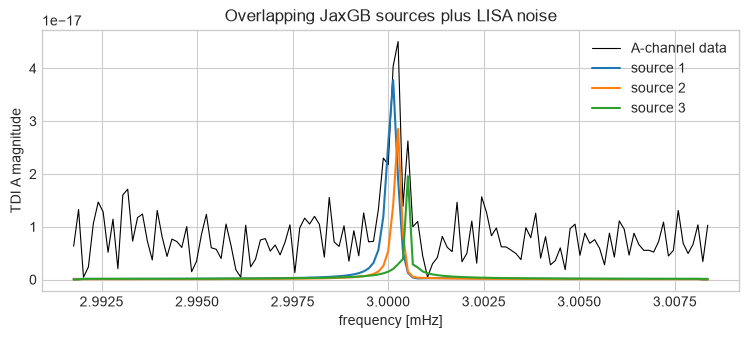

In [4]:
frequencies = np.array([3e-3, 3.00012e-3, 3.00025e-3])
true_scales = np.array([1.0, 0.72, 0.48])
catalogue = GBObject(
    f0=frequencies,
    fdot=np.array([1e-17, 0.5e-17, 1.5e-17]),
    A=np.full(3, 2e-22),
    ra=np.array([1.0, 1.4, 2.0]),
    dec=np.array([0.4, -0.2, 0.7]),
    psi=np.array([0.3, 0.8, 1.1]),
    iota=np.array([0.8, 1.2, 0.5]),
    phi0=np.array([0.2, 1.5, 2.4]),
    t_init=0.0,
)
all_parameters = catalogue.to_jaxgb_array(t0=0)
kmins = np.asarray(simulator.get_kmin(all_parameters[:, 0]))
kmin = int(kmins.min())
kmax = int(kmins.max() + simulator.n)
templates = []
for row in np.asarray(all_parameters):
    a, e, _ = simulator.sum_tdi(
        row[None, :], kmin, kmax, tdi_generation=2, tdi_combination="AET"
    )
    templates.append(np.stack([np.asarray(a), np.asarray(e)]))
templates = np.asarray(templates)
common_frequency = np.arange(kmin, kmax) / t_obs
common_psd = np.stack(
    [
        get_sensitivity(
            common_frequency, sens_fn=A1TDISens, stochastic_params=(t_obs,)
        ),
        get_sensitivity(
            common_frequency, sens_fn=E1TDISens, stochastic_params=(t_obs,)
        ),
    ]
)
noise = np.sqrt(common_psd / (4 * df)) * (
    rng.normal(size=common_psd.shape) + 1j * rng.normal(size=common_psd.shape)
)
data = np.sum(true_scales[:, None, None] * templates, axis=0) + noise


def global_inner(a, b):
    return 4 * df * np.real(np.sum(np.conj(a) * b / common_psd))


fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(
    1e3 * common_frequency, np.abs(data[0]), color="k", lw=0.8, label="A-channel data"
)
for i, h in enumerate(templates):
    ax.plot(
        1e3 * common_frequency, np.abs(true_scales[i] * h[0]), label=f"source {i+1}"
    )
ax.set(
    xlabel="frequency [mHz]",
    ylabel="TDI A magnitude",
    title="Overlapping JaxGB sources plus LISA noise",
)
ax.legend()
plt.show()

true              [1.   0.72 0.48]
one pass          [1.027 0.719 0.517]
joint mean        [1.071 0.721 0.521]
Gibbs mean        [1.073 0.725 0.52 ]
Gibbs uncertainty [0.083 0.113 0.106]


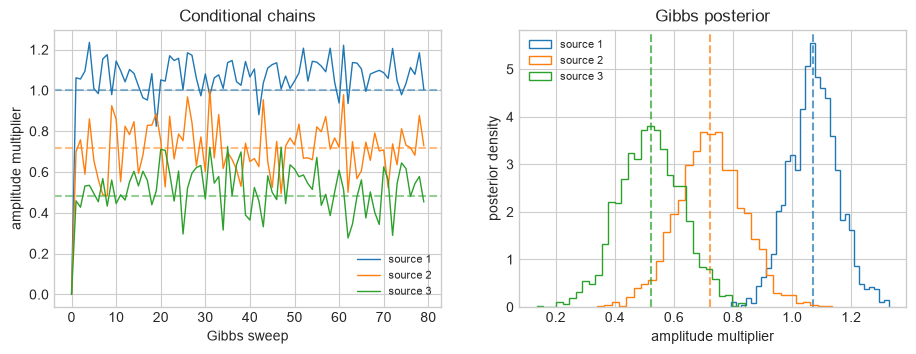

In [5]:
# A one-pass subtraction is order-dependent because later blocks inherit
# the errors left by earlier ones.
sequential = np.zeros(3)
residual = data.copy()
for i, h in enumerate(templates):
    sequential[i] = global_inner(h, residual) / global_inner(h, h)
    residual -= sequential[i] * h

# Exact blocked Gibbs updates for the three amplitude coefficients. With a flat
# prior, each one-dimensional conditional posterior is Gaussian.
n_sweeps = 2000
gibbs_state = np.zeros(3)
gibbs_history = [gibbs_state.copy()]
gibbs_substates = []
gibbs_active_blocks = []
gibbs_conditional_means = []
gibbs_conditional_sds = []
for sweep in range(n_sweeps):
    for i, h in enumerate(templates):
        conditional_residual = (
            data
            - np.sum(gibbs_state[:, None, None] * templates, axis=0)
            + gibbs_state[i] * h
        )
        precision = global_inner(h, h)
        conditional_mean = global_inner(h, conditional_residual) / precision
        conditional_sd = 1 / np.sqrt(precision)
        gibbs_state[i] = rng.normal(conditional_mean, conditional_sd)
        gibbs_substates.append(gibbs_state.copy())
        gibbs_active_blocks.append(i)
        gibbs_conditional_means.append(conditional_mean)
        gibbs_conditional_sds.append(conditional_sd)
    gibbs_history.append(gibbs_state.copy())
gibbs_history = np.asarray(gibbs_history)
gibbs_substates = np.asarray(gibbs_substates)
gibbs_active_blocks = np.asarray(gibbs_active_blocks)
gibbs_conditional_means = np.asarray(gibbs_conditional_means)
gibbs_conditional_sds = np.asarray(gibbs_conditional_sds)
gibbs_samples = gibbs_history[400:]

# The simultaneous weighted least-squares solution is the Gaussian posterior
# mean, providing an independent check on the Gibbs chain.
whitened_templates = (
    (np.sqrt(4 * df / common_psd)[None, :, :] * templates).reshape(3, -1).T
)
whitened_data = (np.sqrt(4 * df / common_psd) * data).ravel()
design = np.vstack([whitened_templates.real, whitened_templates.imag])
target = np.r_[whitened_data.real, whitened_data.imag]
joint = np.linalg.lstsq(design, target, rcond=None)[0]

print("true             ", np.round(true_scales, 3))
print("one pass         ", np.round(sequential, 3))
print("joint mean       ", np.round(joint, 3))
print("Gibbs mean       ", np.round(gibbs_samples.mean(axis=0), 3))
print("Gibbs uncertainty", np.round(gibbs_samples.std(axis=0), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for i in range(3):
    axes[0].plot(gibbs_history[:80, i], lw=1, label=f"source {i+1}")
    axes[0].axhline(true_scales[i], color=f"C{i}", ls="--", alpha=0.5)
    axes[1].hist(
        gibbs_samples[:, i],
        bins=32,
        density=True,
        histtype="step",
        color=f"C{i}",
        label=f"source {i+1}",
    )
    axes[1].axvline(joint[i], color=f"C{i}", ls="--", alpha=0.7)
axes[0].set(
    xlabel="Gibbs sweep", ylabel="amplitude multiplier", title="Conditional chains"
)
axes[1].set(
    xlabel="amplitude multiplier", ylabel="posterior density", title="Gibbs posterior"
)
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

### Animation: one conditional block at a time

Every frame below is **one block update**, not one completed sweep. The left
panel shows the first two amplitude coordinates of the joint posterior; a
source-1 draw moves horizontally and a source-2 draw vertically. Source 3 is
not one of those axes, so its update leaves the dot fixed while still changing
the shared residual on the right.

The right panel shows what is handed to the next block. The highlighted source
is updated conditional on the current estimates of all the others, then its new
waveform is subtracted from the shared data.

**Watch for:** Why can the conditional draw for one source move when
another source was updated in the preceding frame, even though the data never
changed?

In [6]:
# Start after a few sweeps so the narrow posterior contours remain visible.
animation_start = 15
animation_stop = animation_start + 36
animation_states = gibbs_substates[animation_start:animation_stop]
animation_blocks = gibbs_active_blocks[animation_start:animation_stop]
animation_means = gibbs_conditional_means[animation_start:animation_stop]
animation_sds = gibbs_conditional_sds[animation_start:animation_stop]
animation_initial = gibbs_substates[animation_start - 1]
animation_path = np.vstack([animation_initial, animation_states])

amplitude_precision = np.array(
    [[global_inner(first, second) for second in templates] for first in templates]
)
amplitude_covariance = np.linalg.inv(amplitude_precision)
covariance_12 = amplitude_covariance[:2, :2]
sigma_12 = np.sqrt(np.diag(covariance_12))
a1_grid = np.linspace(joint[0] - 4 * sigma_12[0], joint[0] + 4 * sigma_12[0], 120)
a2_grid = np.linspace(joint[1] - 4 * sigma_12[1], joint[1] + 4 * sigma_12[1], 120)
A1_GRID, A2_GRID = np.meshgrid(a1_grid, a2_grid)
offsets_12 = np.stack([A1_GRID - joint[0], A2_GRID - joint[1]], axis=-1)
mahalanobis_12 = np.einsum(
    "...i,ij,...j->...", offsets_12, np.linalg.inv(covariance_12), offsets_12
)
posterior_12 = np.exp(-0.5 * mahalanobis_12)

fig, (posterior_ax, residual_ax) = plt.subplots(1, 2, figsize=(12, 4.5))
posterior_ax.contour(
    A1_GRID,
    A2_GRID,
    posterior_12,
    levels=np.exp(-0.5 * np.array([9.0, 4.0, 1.0])),
    colors=".65",
)
posterior_ax.plot(
    true_scales[0], true_scales[1], "*", color="k", ms=10, label="injected"
)
posterior_ax.plot(joint[0], joint[1], "+", color="C3", ms=10, mew=2, label="joint mean")
(gibbs_path_line,) = posterior_ax.plot([], [], color=".7", lw=1)
(gibbs_step_line,) = posterior_ax.plot([], [], lw=3)
(gibbs_point,) = posterior_ax.plot([], [], "o", color="k", ms=5)
posterior_ax.set(
    xlabel="source 1 amplitude",
    ylabel="source 2 amplitude",
    title="conditional moves through the joint posterior",
)
posterior_ax.legend(fontsize=8)

animation_whitening = np.sqrt(4 * df / common_psd[0])
animation_data_A = np.abs(data[0]) * animation_whitening
residual_ax.plot(
    1e3 * common_frequency, animation_data_A, color=".82", lw=0.8, label="shared data"
)
(residual_line,) = residual_ax.plot(
    [], [], color="k", lw=1, label="residual after update"
)
(active_model_line,) = residual_ax.plot(
    [], [], color=".5", lw=2, label="active source (block colour)"
)
conditional_text = residual_ax.text(
    0.02,
    0.95,
    "",
    transform=residual_ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
)
residual_ax.set(
    xlim=(1e3 * common_frequency.min(), 1e3 * common_frequency.max()),
    ylim=(0, 1.08 * animation_data_A.max()),
    xlabel="frequency [mHz]",
    ylabel="whitened A magnitude",
)
residual_ax.legend(fontsize=8, loc="upper right")


def animate_gibbs_block(frame):
    state = animation_states[frame]
    previous = animation_path[frame]
    active = int(animation_blocks[frame])
    colour = f"C{active}"
    gibbs_path_line.set_data(
        animation_path[: frame + 2, 0], animation_path[: frame + 2, 1]
    )
    gibbs_step_line.set_data([previous[0], state[0]], [previous[1], state[1]])
    gibbs_step_line.set_color(colour)
    gibbs_point.set_data([state[0]], [state[1]])
    residual_after = data - np.sum(state[:, None, None] * templates, axis=0)
    residual_line.set_data(
        1e3 * common_frequency, np.abs(residual_after[0]) * animation_whitening
    )
    active_model_line.set_data(
        1e3 * common_frequency,
        np.abs(state[active] * templates[active, 0]) * animation_whitening,
    )
    active_model_line.set_color(colour)
    conditional_text.set_text(
        f"draw a{active+1} from its conditional\n"
        f"mean {animation_means[frame]:.3f}, sd {animation_sds[frame]:.3f}\n"
        f"new value {state[active]:.3f}"
    )
    posterior_ax.set_title(f"block {active+1}: condition on the other sources")
    residual_ax.set_title(f"pass this residual to block {(active+1)%3+1}")
    return (
        gibbs_path_line,
        gibbs_step_line,
        gibbs_point,
        residual_line,
        active_model_line,
        conditional_text,
    )


gibbs_block_animation = FuncAnimation(
    fig, animate_gibbs_block, frames=len(animation_states), interval=320
)
plt.close(fig)
show_animation(gibbs_block_animation)

### Question

Reverse the order of the one-pass source subtraction. Compare the final residual norm with the blocked chain. Why can one-pass subtraction depend on ordering?

In [7]:
reverse_order = [2, 1, 0]
# Your code here: repeat the one-pass subtraction in reverse_order, then compare
# its final residual norm with the forward pass and with the blocked chain.

<details>
<summary>Hint</summary>

Each early subtraction is conditional on an incomplete residual. Its error is inherited by later blocks and is never revisited.

</details>


> **📌 End of the live route**
>
> The essential global-fit idea is residual communication: every source block
> sees the data after subtracting the current models for all other blocks. A
> one-pass subtraction freezes early mistakes; repeated conditional updates can
> revisit them.
>
> The extension below adds source searches, nonlinear parameters, a noise block,
> Fisher-scaled proposals, and a fixed-count catalogue comparison. Those are
> important research ideas, but not prerequisites for understanding the shared
> residual.

## Extension: search, seed, and cycle a miniature catalogue

## 2. A miniature teaching-toy global fit

The three-amplitude demo above kept the source *shapes* fixed so every
conditional was exactly Gaussian. Now we drop that: two source classes with
unknown nonlinear parameters, an unknown noise level, and no idea where the
sources are until we look.

The data model is the one from the wheel, restricted to two classes:

$$
d(f)=\underbrace{A_{\rm MBHB}\,h(f;\mathcal M,t_c,\phi_c)}_{\text{one chirp}}
+\sum_{i}\underbrace{A_i\,g(f;f_{0,i},\phi_{0,i})}_{\text{monochromatic binaries}}
+\;n(f;\eta).
$$

- **Massive black-hole binary.** A restricted post-Newtonian inspiral in the
  stationary-phase approximation, sweeping upward through the band:

$$
\tilde h(f)\propto f^{-7/6}\exp\left[i\left(2\pi f t_c-\phi_c-\frac{\pi}{4}
+\frac{3}{128}(\pi\mathcal M f)^{-5/3}\right)\right].
$$

- **Galactic binaries.** Monochromatic over the observation, so each one is a
  sinc kernel of width $1/T_{\rm obs}$ centred on $f_0$. Real GBs also drift in
  frequency and are modulated by the constellation motion; Section 4 used the
  full JaxGB response for exactly that reason.
- **Noise.** A smooth analytic LISA-like PSD with one unknown overall scale
  $\eta$, so the noise level is inferred rather than assumed.

We parametrise each source by its **signal-to-noise ratio** rather than a raw
amplitude, so the numbers are directly interpretable and the truth is known.

The pipeline is the real one, in miniature:

1. **Search.** Find the sources. Nothing is known a priori.
2. **Seed.** Use the search estimates as the starting point.
3. **Gibbs.** Cycle blocks, each conditional on the current residual.

This is still an inspiral-only classroom model: it omits merger and ringdown,
the moving LISA response, gaps, and non-stationary noise. Its purpose is to
make the search--seed--cycle logic visible, not to claim a production global
fit.

In [8]:
from scipy.stats import gamma as gamma_dist

T_OBS_GF = 90 * 86400.0
DF_GF = 1.0 / T_OBS_GF
K_LO, K_HI = int(2.0e-3 / DF_GF), int(6.0e-3 / DF_GF)
gf_frequency = np.arange(K_LO, K_HI) * DF_GF
N_BINS = gf_frequency.size
# A smooth, analytic stand-in for the LISA noise PSD.
BASE_PSD = 2.0e-40 * (1 + (4e-4 / gf_frequency) ** 2) + 4.0e-41
MSUN_SECONDS = 4.9254909476412675e-6


def gf_inner(a, b, psd=BASE_PSD):
    return 4 * DF_GF * np.real(np.sum(np.conj(a) * b / psd))


def gf_complex_inner(a, b, psd=BASE_PSD):
    """Complex overlap; its modulus maximises over an overall phase."""
    return 4 * DF_GF * np.sum(np.conj(a) * b / psd)


def gb_shape(f0, phi0):
    """Monochromatic source observed for a finite time: a sinc kernel."""
    return np.exp(1j * phi0) * np.sinc((gf_frequency - f0) * T_OBS_GF)


def mbhb_shape(chirp_mass, t_c, phi_c):
    """Restricted post-Newtonian inspiral, stationary-phase approximation."""
    mass_seconds = chirp_mass * MSUN_SECONDS
    phase = (
        2 * np.pi * gf_frequency * t_c
        - phi_c
        - np.pi / 4
        + (3 / 128) * (np.pi * mass_seconds * gf_frequency) ** (-5 / 3)
    )
    return gf_frequency ** (-7 / 6) * np.exp(1j * phase)


def unit_norm(shape):
    return shape / np.sqrt(gf_inner(shape, shape))


def gb_template(params):
    """params = (f0, snr, phi0). The amplitude parameter *is* the SNR."""
    return params[1] * unit_norm(gb_shape(params[0], params[2]))


def mbhb_template(params):
    """params = (chirp_mass, t_c, snr, phi_c)."""
    return params[2] * unit_norm(mbhb_shape(params[0], params[1], params[3]))


TRUE_GB = np.array(
    [[3.0004e-3, 18.0, 0.7], [3.6207e-3, 25.0, 2.1], [4.7103e-3, 12.0, 4.4]]
)
TRUE_MBHB = np.array([4.0e5, 0.55 * T_OBS_GF, 60.0, 1.1])

gf_rng = np.random.default_rng(7)
injected = sum(gb_template(g) for g in TRUE_GB) + mbhb_template(TRUE_MBHB)
gf_noise = np.sqrt(BASE_PSD / (4 * DF_GF)) * (
    gf_rng.normal(size=N_BINS) + 1j * gf_rng.normal(size=N_BINS)
)
gf_data = injected + gf_noise

print(f"analysis band: {gf_frequency[0]*1e3:.1f}-{gf_frequency[-1]*1e3:.1f} mHz")
print(f"frequency bins: {N_BINS}   bin width 1/T_obs = {DF_GF:.3e} Hz")
print(f"injected total SNR: {np.sqrt(gf_inner(injected, injected)):.1f}")
print(
    f"noise check (n|n)/N_bins = {gf_inner(gf_noise, gf_noise)/N_BINS:.3f} (expect ~2)"
)

analysis band: 2.0-6.0 mHz
frequency bins: 31104   bin width 1/T_obs = 1.286e-07 Hz
injected total SNR: 68.5
noise check (n|n)/N_bins = 1.991 (expect ~2)


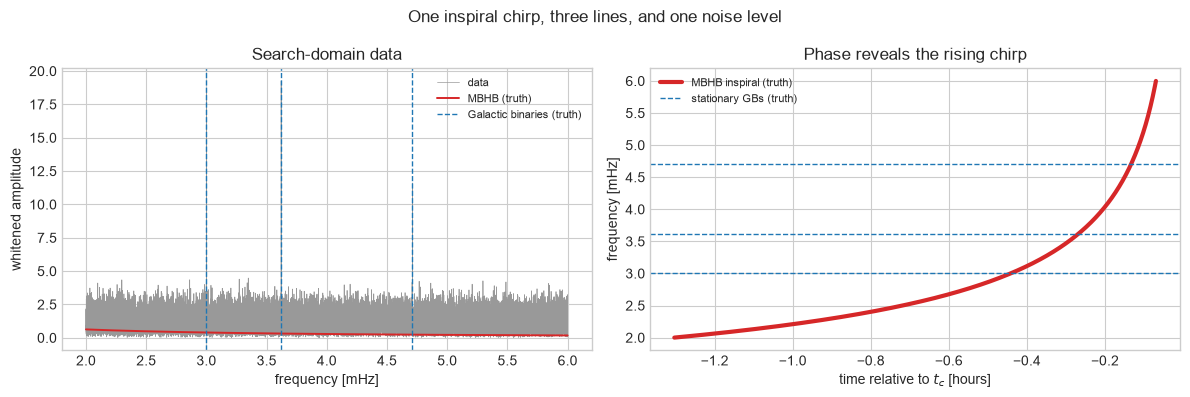

In [9]:
whitened_data = np.abs(gf_data) * np.sqrt(4 * DF_GF / BASE_PSD)
whitened_mbhb = np.abs(mbhb_template(TRUE_MBHB)) * np.sqrt(4 * DF_GF / BASE_PSD)

# The magnitude panel is the object searched below, but magnitude alone throws
# away the phase evolution that makes an inspiral recognisable as a chirp.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
axes[0].plot(gf_frequency * 1e3, whitened_data, lw=0.5, color="0.6", label="data")
axes[0].plot(
    gf_frequency * 1e3, whitened_mbhb, lw=1.4, color="C3", label="MBHB (truth)"
)
for i, g in enumerate(TRUE_GB):
    axes[0].axvline(
        g[0] * 1e3,
        color="C0",
        ls="--",
        lw=1,
        label="Galactic binaries (truth)" if i == 0 else None,
    )
axes[0].set(
    xlabel="frequency [mHz]", ylabel="whitened amplitude", title="Search-domain data"
)
axes[0].legend(fontsize=8)

# The derivative of the stationary-phase Fourier phase gives the time at which
# each frequency is emitted. This is the same injected template, not a second
# waveform model or a simulated merger/ringdown.
mass_seconds = TRUE_MBHB[0] * MSUN_SECONDS
track_time = TRUE_MBHB[1] - (5 / 256) * mass_seconds * (
    np.pi * mass_seconds * gf_frequency
) ** (-8 / 3)
hours_from_tc = (track_time - TRUE_MBHB[1]) / 3600
axes[1].plot(
    hours_from_tc, gf_frequency * 1e3, color="C3", lw=3, label="MBHB inspiral (truth)"
)
for i, g in enumerate(TRUE_GB):
    axes[1].axhline(
        g[0] * 1e3,
        color="C0",
        ls="--",
        lw=1,
        label="stationary GBs (truth)" if i == 0 else None,
    )
axes[1].set(
    xlabel=r"time relative to $t_c$ [hours]",
    ylabel="frequency [mHz]",
    title="Phase reveals the rising chirp",
)
axes[1].legend(fontsize=8)
fig.suptitle("One inspiral chirp, three lines, and one noise level")
fig.tight_layout()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-global-fit.png" alt="expected output: lisa-global-fit" style="max-width:100%">

</details>

### Stage 1: search

Nothing above is known to the analysis. Two searches, both reusing machinery
from earlier notebooks:

- **MBHB.** Maximise the overlap over $(\mathcal M,t_c)$. Amplitude and phase
  come out analytically, and $t_c$ enters only as $e^{2\pi i f t_c}$, so **one
  inverse FFT scans every arrival time at once**. This is exactly the
  matched-filter trick from notebook 02, Section 3.
- **Galactic binaries.** After removing the MBHB estimate, a monochromatic
  source sitting exactly on a Fourier bin has all its power in that bin, so the
  search statistic is just the **whitened periodogram**. Peaks above 7 are kept.
- **Refinement.** Real sources do not sit on bin centres, so a candidate found
  at a bin loses power to leakage. A sub-bin scan recovers it. Skipping this
  step leaves the sampler stranded in the wrong Fourier bin.

In [10]:
N_FFT = 1 << 17
tc_axis = np.arange(N_FFT) / (N_FFT * DF_GF)


def mbhb_search(residual, chirp_mass_grid):
    """Grid over chirp mass; one inverse FFT covers all coalescence times."""
    best = (-1.0, None, None, None)
    for chirp_mass in chirp_mass_grid:
        shape = mbhb_shape(chirp_mass, 0.0, 0.0)
        norm = np.sqrt(gf_inner(shape, shape))
        padded = np.zeros(N_FFT, dtype=complex)
        padded[K_LO:K_HI] = np.conj(residual) * shape / BASE_PSD
        overlap = 4 * DF_GF * N_FFT * np.fft.ifft(padded) / norm
        peak = int(np.argmax(np.abs(overlap)))
        if np.abs(overlap[peak]) > best[0]:
            best = (
                np.abs(overlap[peak]),
                chirp_mass,
                tc_axis[peak],
                np.angle(overlap[peak]),
            )
    return best


search_start = time.time()
snr_hat, mass_hat, tc_hat, phase_hat = mbhb_search(
    gf_data, np.geomspace(2.0e5, 8.0e5, 120)
)
snr_hat, mass_hat, tc_hat, phase_hat = mbhb_search(
    gf_data, np.geomspace(mass_hat * 0.97, mass_hat * 1.03, 60)
)
mbhb_seed = np.array([mass_hat, tc_hat, snr_hat, phase_hat])
print(
    f"MBHB found: SNR {snr_hat:.1f}, chirp mass {mass_hat:.4g} "
    f"(true {TRUE_MBHB[0]:.4g}), t_c/T {tc_hat/T_OBS_GF:.5f} "
    f"(true {TRUE_MBHB[1]/T_OBS_GF:.5f})"
)

residual_after_mbhb = gf_data - mbhb_template(mbhb_seed)
periodogram = np.abs(residual_after_mbhb) * np.sqrt(4 * DF_GF / BASE_PSD)
candidates, index = [], 1
while index < N_BINS - 1:
    if (
        periodogram[index] > 7.0
        and periodogram[index] >= periodogram[index - 1]
        and periodogram[index] >= periodogram[index + 1]
    ):
        candidates.append(index)
        index += 8
    else:
        index += 1

gb_seed = []
for index in candidates:
    scan = gf_frequency[index] + np.linspace(-1.5, 1.5, 121) * DF_GF
    best = (-1.0, None)
    for f0 in scan:
        shape = unit_norm(gb_shape(f0, 0.0))
        overlap = gf_complex_inner(residual_after_mbhb, shape)
        if np.abs(overlap) > best[0]:
            best = (np.abs(overlap), [f0, np.abs(overlap), np.angle(overlap)])
    gb_seed.append(best[1])
gb_seed = np.array(gb_seed)
print(
    f"\nGalactic binaries found: {len(gb_seed)}  (search took "
    f"{time.time()-search_start:.1f} s)"
)
for i, seed in enumerate(gb_seed):
    print(
        f"  f0 = {seed[0]*1e3:.6f} mHz (true {TRUE_GB[i,0]*1e3:.6f}), "
        f"SNR {seed[1]:.1f} (true {TRUE_GB[i,1]:.0f})"
    )

MBHB found: SNR 60.2, chirp mass 3.96e+05 (true 4e+05), t_c/T 0.55000 (true 0.55000)

Galactic binaries found: 3  (search took 0.5 s)
  f0 = 3.000402 mHz (true 3.000400), SNR 19.2 (true 18)
  f0 = 3.620702 mHz (true 3.620700), SNR 25.8 (true 25)
  f0 = 4.710291 mHz (true 4.710300), SNR 12.6 (true 12)


### Stage 2: Gibbs, one block per source

Blocks: the MBHB, each Galactic binary, and the noise level. One sweep visits
all of them; each sees only its own conditional residual.

**Proposals matter.** The MBHB parameters are correlated and fantastically
well constrained: $t_c$ is measured to a second out of a 90-day window. An
isotropic proposal is rejected essentially always. So we build the **Fisher
matrix at the seed and propose along its eigen-directions** — the payoff for
the Fisher extension in notebook 05, Section 3, and what production
samplers actually do.

The Fisher matrix here is numerically brutal: $\sigma(f_0)\sim10^{-9}$ while
$\sigma(\rho)\sim1$, a condition number near $10^{18}$. We rescale to unit
diagonal before inverting, otherwise the amplitude errors come out meaningless.

**The noise block is a true Gibbs step.** With $\eta$ scaling the PSD,

$$
p(\eta\mid r)\propto\eta^{-N_{\rm bins}}
\exp\left[-\frac{(r\mid r)_{\rm base}}{2\eta}\right],
$$

an inverse-gamma distribution we can draw from exactly. Source blocks use
Metropolis steps — hence **Metropolis-within-Gibbs**.

In [11]:
def fisher_proposal(template_fn, params, steps):
    """Fisher inverse, rescaled to unit diagonal for numerical stability."""
    derivatives = []
    for i in range(len(params)):
        up, down = params.copy(), params.copy()
        up[i] += steps[i]
        down[i] -= steps[i]
        derivatives.append((template_fn(up) - template_fn(down)) / (2 * steps[i]))
    fisher = np.array([[gf_inner(a, b) for b in derivatives] for a in derivatives])
    scale = np.sqrt(np.diag(fisher))
    covariance = np.linalg.inv(fisher / np.outer(scale, scale)) / np.outer(scale, scale)
    return np.linalg.cholesky(covariance) * 2.4 / np.sqrt(len(params))


mbhb_state = mbhb_seed.copy()
gb_state = gb_seed.copy()
noise_scale = 1.0
n_sources = len(gb_state)

mbhb_jump = fisher_proposal(
    mbhb_template, mbhb_state, np.array([mbhb_state[0] * 1e-5, 0.05, 0.01, 1e-3])
)
gb_jumps = [
    fisher_proposal(gb_template, g, np.array([1e-11, 0.01, 1e-3])) for g in gb_state
]
print(
    "MBHB Fisher sigma (chirp mass, t_c, SNR, phase):",
    np.round(np.sqrt(np.diag(mbhb_jump @ mbhb_jump.T)) * np.sqrt(4) / 2.4, 4),
)
print("A pure amplitude should give sigma(SNR) = 1 exactly.")

MBHB Fisher sigma (chirp mass, t_c, SNR, phase): [1.2572467e+03 7.1652000e+00 1.0000000e+00 2.4600000e-01]
A pure amplitude should give sigma(SNR) = 1 exactly.


In [12]:
N_SWEEPS, BURN_IN = 1800, 700
mbhb_model = mbhb_template(mbhb_state)
gb_models = [gb_template(g) for g in gb_state]

chain_mbhb = np.zeros((N_SWEEPS, 4))
chain_gb = np.zeros((N_SWEEPS, n_sources, 3))
chain_noise = np.zeros(N_SWEEPS)
accepted = np.zeros(1 + n_sources)
gibbs_rng = np.random.default_rng(11)


def scaled_chi_squared(residual, scale):
    return gf_inner(residual, residual) / scale


gibbs_start = time.time()
for sweep in range(N_SWEEPS):
    # --- block 1: the massive black-hole binary ---
    conditional = gf_data - sum(gb_models)
    current = scaled_chi_squared(conditional - mbhb_model, noise_scale)
    proposal = mbhb_state + mbhb_jump @ gibbs_rng.normal(size=4)
    if proposal[2] > 0:
        trial = mbhb_template(proposal)
        if np.log(gibbs_rng.uniform()) < -0.5 * (
            scaled_chi_squared(conditional - trial, noise_scale) - current
        ):
            mbhb_state, mbhb_model = proposal, trial
            accepted[0] += 1

    # --- blocks 2..N: one per Galactic binary ---
    for i in range(n_sources):
        others = mbhb_model + sum(gb_models[j] for j in range(n_sources) if j != i)
        conditional = gf_data - others
        current = scaled_chi_squared(conditional - gb_models[i], noise_scale)
        proposal = gb_state[i] + gb_jumps[i] @ gibbs_rng.normal(size=3)
        if proposal[1] > 0:
            trial = gb_template(proposal)
            if np.log(gibbs_rng.uniform()) < -0.5 * (
                scaled_chi_squared(conditional - trial, noise_scale) - current
            ):
                gb_state[i], gb_models[i] = proposal, trial
                accepted[1 + i] += 1

    # --- final block: the noise level, an exact inverse-gamma draw ---
    residual = gf_data - mbhb_model - sum(gb_models)
    noise_scale = (gf_inner(residual, residual) / 2) / gibbs_rng.gamma(N_BINS, 1.0)

    chain_mbhb[sweep] = mbhb_state
    chain_gb[sweep] = gb_state
    chain_noise[sweep] = noise_scale

print(f"{N_SWEEPS} sweeps in {time.time()-gibbs_start:.1f} s")
print("block acceptance rates:", np.round(accepted / N_SWEEPS, 2))

1800 sweeps in 4.3 s
block acceptance rates: [0.28 0.34 0.34 0.27]


In [13]:
samples_mbhb = chain_mbhb[BURN_IN:]
samples_gb = chain_gb[BURN_IN:]
samples_noise = chain_noise[BURN_IN:]


def report(name, values, truth, fmt="12.6g"):
    low, median, high = np.percentile(values, [5, 50, 95])
    flag = "ok " if low <= truth <= high else "OUT"
    print(
        f"  {name:12s}{median:{fmt}} [{low:{fmt}},{high:{fmt}}] "
        f"truth {truth:{fmt}}  {flag}"
    )


print("MBHB block")
for j, name in enumerate(["chirp mass", "t_c [s]", "SNR", "phase"]):
    report(name, samples_mbhb[:, j], TRUE_MBHB[j])
print("Galactic-binary blocks")
for i in range(n_sources):
    report(f"GB{i} f0 [mHz]", samples_gb[:, i, 0] * 1e3, TRUE_GB[i, 0] * 1e3, "12.7g")
    report(f"GB{i} SNR", samples_gb[:, i, 1], TRUE_GB[i, 1])
print("Noise block")
report("PSD scale", samples_noise, 1.0)

final_residual = gf_data - mbhb_model - sum(gb_models)
print(
    f"\nfinal (r|r)/N_bins = "
    f"{gf_inner(final_residual, final_residual)/N_BINS:.3f}  (pure noise gives ~2)"
)

MBHB block
  chirp mass        400910 [      398891,      403487] truth       400000  ok 
  t_c [s]       4.2768e+06 [ 4.27678e+06, 4.27681e+06] truth   4.2768e+06  ok 
  SNR              60.3607 [     58.9898,      61.835] truth           60  ok 
  phase           0.918396 [    0.430819,     1.28815] truth          1.1  ok 
Galactic-binary blocks
  GB0 f0 [mHz]    3.000401 [    3.000393,    3.000407] truth       3.0004  ok 
  GB0 SNR           18.901 [     17.5539,     20.7594] truth           18  ok 
  GB1 f0 [mHz]    3.620703 [    3.620698,    3.620707] truth       3.6207  ok 
  GB1 SNR          25.7602 [     24.4447,     27.5776] truth           25  ok 
  GB2 f0 [mHz]    4.710292 [    4.710283,    4.710301] truth       4.7103  ok 
  GB2 SNR          12.5772 [     11.0531,     14.1877] truth           12  ok 
Noise block
  PSD scale       0.995199 [    0.986641,      1.0049] truth            1  ok 

final (r|r)/N_bins = 1.991  (pure noise gives ~2)


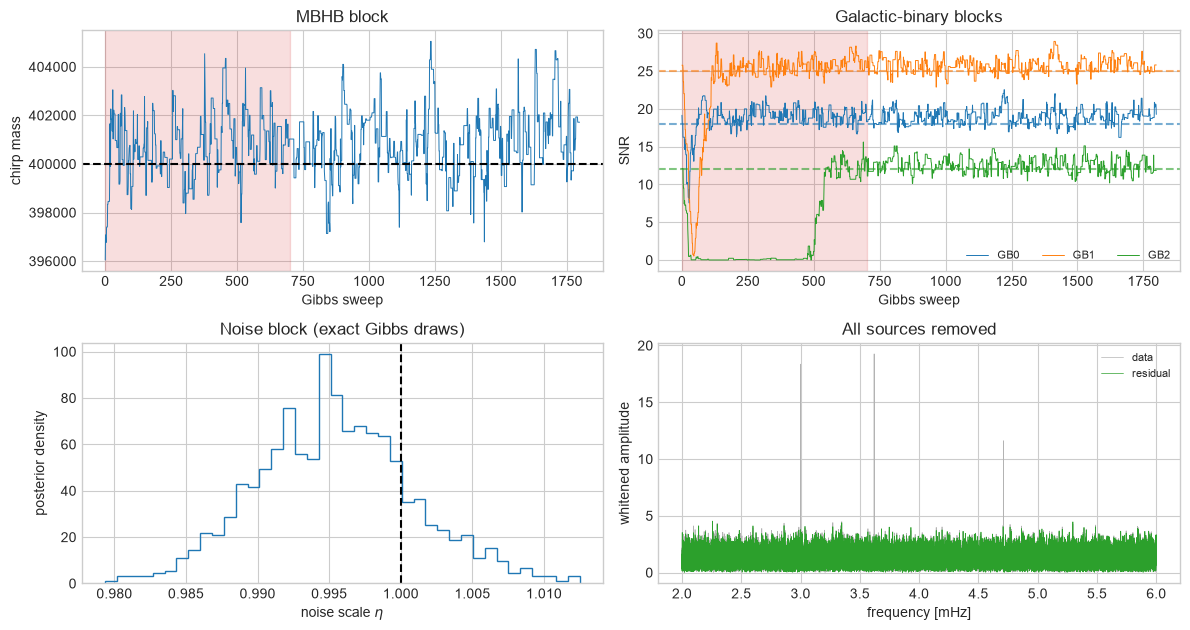

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))

axes[0, 0].plot(chain_mbhb[:, 0], lw=0.7)
axes[0, 0].axhline(TRUE_MBHB[0], color="k", ls="--")
axes[0, 0].axvspan(0, BURN_IN, color="C3", alpha=0.15)
axes[0, 0].set(xlabel="Gibbs sweep", ylabel="chirp mass", title="MBHB block")

for i in range(n_sources):
    axes[0, 1].plot(chain_gb[:, i, 1], lw=0.7, color=f"C{i}", label=f"GB{i}")
    axes[0, 1].axhline(TRUE_GB[i, 1], color=f"C{i}", ls="--", alpha=0.6)
axes[0, 1].axvspan(0, BURN_IN, color="C3", alpha=0.15)
axes[0, 1].set(xlabel="Gibbs sweep", ylabel="SNR", title="Galactic-binary blocks")
axes[0, 1].legend(fontsize=8, ncol=3)

axes[1, 0].hist(samples_noise, bins=40, density=True, histtype="step", color="C0")
axes[1, 0].axvline(1.0, color="k", ls="--")
axes[1, 0].set(
    xlabel=r"noise scale $\eta$",
    ylabel="posterior density",
    title="Noise block (exact Gibbs draws)",
)

axes[1, 1].plot(gf_frequency * 1e3, whitened_data, lw=0.5, color="0.7", label="data")
axes[1, 1].plot(
    gf_frequency * 1e3,
    np.abs(final_residual) * np.sqrt(4 * DF_GF / BASE_PSD),
    lw=0.5,
    color="C2",
    label="residual",
)
axes[1, 1].set(
    xlabel="frequency [mHz]", ylabel="whitened amplitude", title="All sources removed"
)
axes[1, 1].legend(fontsize=8)
fig.tight_layout()
plt.show()

> **⚠️ Residuals carry the history of a global fit**
>
> After subtracting one imperfect source, its remaining error is no longer
> labelled “source 1”: it is structure in the residual. The next source block or
> the noise block can absorb it, biasing their inferences. That is why global
> methods repeatedly update shared residuals (or sample all blocks jointly), and
> why “the residual looks quiet” is a necessary but not sufficient check.

**Look at the GB2 trace before trusting any number.** The
weakest source (injected at SNR 12) collapses to zero amplitude early on and
stays there for several hundred sweeps before recovering. Once its amplitude
is near zero its frequency is unconstrained, so $f_0$ random-walks away and the
block has to find its way back.

- This is a genuine sampling pathology, not a plotting artefact, and it is
  common in global fits with weak sources.
- **The slowest block sets the burn-in for the whole chain.** The MBHB block
  converged within a few sweeps; GB2 needed roughly 500. Discarding a burn-in
  chosen from the MBHB trace alone would contaminate every GB2 summary.
- Production codes attack this with parallel tempering and with
  reversible-jump moves that delete and re-add sources deliberately, rather
  than waiting for a fixed-dimension chain to wander back.
- It is also the honest form of the question "is this source really there?",
  which Section 3 takes up.

What this miniature keeps from a real global fit:

- Sources are **found**, not assumed, and the fit is seeded from the search.
- Every block conditions on a residual containing the current estimate of every
  other block, so errors propagate exactly as the wheel describes.
- The noise level is inferred jointly with the signals.
- The final residual is statistically consistent with pure noise, which is the
  standard global-fit sanity check.

What it still leaves out:

- Constellation response and TDI: these are plain frequency-domain templates,
  whereas notebook 05, Section 3 used the real moving JaxGB response.
- Sky position, inclination, polarisation, and frequency drift $\dot f_0$.
- A **fixed** source count. Real analyses add and delete sources with
  reversible-jump moves inside the Galactic-binary block.
- Tens of thousands of overlapping sources rather than three, with a confusion
  foreground that is itself part of the noise model.
- Data gaps and non-stationarity, from notebook 08, Section 1.

## 3. A miniature unknown-source-count challenge

LATW Tutorial 6 uses RJMCMC so the number of Galactic binaries is inferred. Here we enumerate all eight subsets of three candidate templates and use BIC only as a fast classroom proxy—not as a replacement for evidence or RJMCMC.

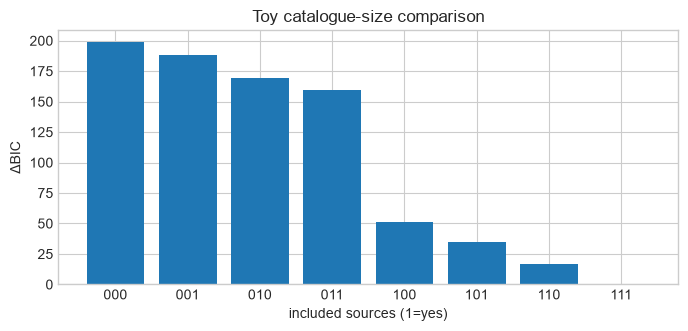

Preferred subset: 111 (the injected subset is 111)


In [15]:
model_scores = []
for included_bits in itertools.product([0, 1], repeat=3):
    included = np.flatnonzero(included_bits)
    model = np.zeros_like(data)
    n_parameters = len(included)
    if n_parameters:
        X = whitened_templates[:, included]
        D = np.vstack([X.real, X.imag])
        coefficients = np.linalg.lstsq(D, target, rcond=None)[0]
        model = np.sum(coefficients[:, None, None] * templates[included], axis=0)
    minus_two_logL = global_inner(data - model, data - model)
    bic = minus_two_logL + n_parameters * np.log(target.size)
    model_scores.append((included_bits, bic))
best = min(score for _, score in model_scores)
labels = ["".join(map(str, bits)) for bits, _ in model_scores]
delta = [score - best for _, score in model_scores]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.bar(labels, delta)
ax.set(
    xlabel="included sources (1=yes)",
    ylabel=r"$\Delta$BIC",
    title="Toy catalogue-size comparison",
)
plt.show()
print(
    "Preferred subset:", labels[int(np.argmin(delta))], "(the injected subset is 111)"
)

<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/07_lisa_pspline_psd.ipynb)

---

# Worked solutions

Everything above this line is the lab notebook, unchanged. Below are the
solutions to its exercises, as cells that actually run: execute the notebook
from the top and every variable they need will already exist.

## Question: does subtraction order matter?

In [16]:
reverse_residual = data.copy()
reverse_amplitudes = np.zeros(3)
for source_index in reverse_order:
    template_i = templates[source_index]
    reverse_amplitudes[source_index] = global_inner(
        template_i, reverse_residual
    ) / global_inner(template_i, template_i)
    reverse_residual -= reverse_amplitudes[source_index] * template_i
print(
    "reverse one-pass residual norm:",
    global_inner(reverse_residual, reverse_residual),
)

reverse one-pass residual norm: 436.8436680983658


One-pass subtraction fits each source to a residual that still contains the
other sources' power. That error is baked into the amplitude and never revisited,
and the next source inherits it — so the answer depends on which source went
first. The blocked chain revisits every source conditional on the current best
estimate of all the others, which is why it converges to the same place
regardless of ordering. This is the entire argument for a global fit over a
subtract-the-loudest pipeline.